MOUNT GDRIVE

In [ ]:
import pandas as pd

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

ValueError: mount failed

LOAD DATASET

In [ ]:
data = pd.read_csv('/content/drive/MyDrive/FARYZA_FYP/dataset/UNSW_NB15_training-set.csv')
print(data.head())

In [ ]:
# Check unique values in 'service' column before encoding
print(data['service'].unique())

# Check how many unique values are there
print(data['service'].nunique())

['-' 'http' 'ftp' 'ftp-data' 'smtp' 'pop3' 'dns' 'snmp' 'ssl' 'dhcp' 'irc'
 'radius' 'ssh']
13


In [ ]:
from sklearn.preprocessing import LabelEncoder

# we create a LabelEncoder object
LE = LabelEncoder()

# encode the 'service' feature for testing
data['service'] = LE.fit_transform(data['service'])

# print
print(data['service'].head())

0    0
1    0
2    0
3    0
4    0
Name: service, dtype: int64


In [ ]:
# Print the original service names and their encoded numbers
service_mapping = dict(zip(LE.classes_, LE.transform(LE.classes_)))
print(service_mapping)


{'-': np.int64(0), 'dhcp': np.int64(1), 'dns': np.int64(2), 'ftp': np.int64(3), 'ftp-data': np.int64(4), 'http': np.int64(5), 'irc': np.int64(6), 'pop3': np.int64(7), 'radius': np.int64(8), 'smtp': np.int64(9), 'snmp': np.int64(10), 'ssh': np.int64(11), 'ssl': np.int64(12)}


In [ ]:
# Count how many times each service appears
service_counts = data['service'].value_counts()

# Show counts with the service names instead of numbers
service_counts_named = service_counts.rename(index=service_mapping)
print(service_counts_named)


service
0     47153
2     21367
5      8287
9      1851
3      1552
4      1396
7       423
11      204
12       30
10       29
1        26
8         9
6         5
Name: count, dtype: int64


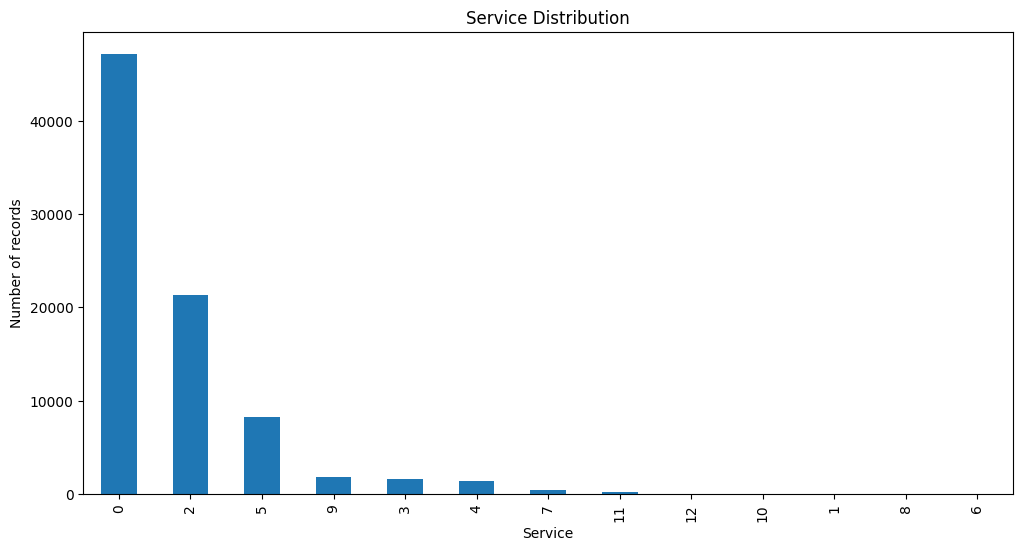

In [ ]:
import matplotlib.pyplot as plt

service_mapping = dict(zip(LE.classes_, LE.transform(LE.classes_)))

# to see how many times each service appears
service_counts = data['service'].value_counts()

# plotting
plt.figure(figsize=(12,6))
service_counts.plot(kind='bar')

# labels and titles
plt.xlabel('Service')
plt.ylabel('Number of records')
plt.title('Service Distribution')

# show
plt.show()

In [ ]:
# Print the mapping between numbers and original service names
service_mapping = dict(zip(le.transform(le.classes_), le.classes_))
print(service_mapping)


NameError: name 'le' is not defined

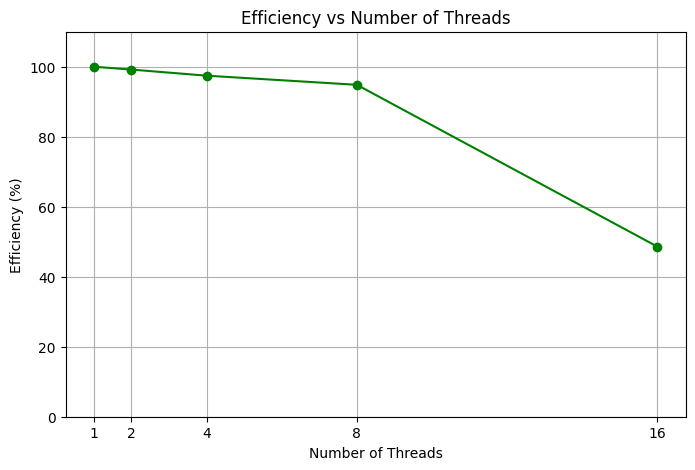

In [1]:
import matplotlib.pyplot as plt

# Data: Threads and corresponding execution times (in milliseconds)
threads = [1, 2, 4, 8, 16]
times = [24996.12, 12601.08, 6413.01, 3294.78, 3215.84]

# Sequential time
T_seq = times[0]

# Calculate speedup and efficiency
speedup = [T_seq / t for t in times]
efficiency = [(s / p) * 100 for s, p in zip(speedup, threads)]

# Plot
plt.figure(figsize=(8, 5))
plt.plot(threads, efficiency, marker='o', linestyle='-', color='green')
plt.title('Efficiency vs Number of Threads')
plt.xlabel('Number of Threads')
plt.ylabel('Efficiency (%)')
plt.grid(True)
plt.ylim(0, 110)
plt.xticks(threads)
plt.show()
